In [1]:
import pandas as pd
import sklearn.preprocessing as preproc
import seaborn as sns

In [2]:
data = pd.read_csv("Diamonds.csv")

In [3]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
data.info()
#we can see the 3 categories, cut, color and clarity are string

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [7]:
data["color"].unique()
#selecting the color category and returning all the unique values

<ArrowStringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str

In [8]:
#this becomes the target variable, use label encoder
#for independant features we use ordinal encoder
#label encoder
le = preproc.LabelEncoder()


In [9]:
data["color"] = le.fit_transform(data["color"])

In [10]:
data["color"].unique()

array([1, 5, 6, 4, 2, 3, 0])

In [11]:
#for example E become 1, I become 5, J became 6, H became 4, F became 2, G became 3 and D became 0

In [17]:
#ordinal encoder
oe = preproc.OrdinalEncoder()

In [18]:
data["clarity"].unique()

<ArrowStringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str

In [20]:
data["clarity"] = oe.fit_transform(data[["clarity"]])
#double brackets mean ordinal encoder

In [21]:
data["clarity"].unique()

array([3., 2., 4., 5., 7., 6., 0., 1.])

In [22]:
#we use label for our target variable and ordinal for independant variables

In [24]:
#dummy encoding or one hot encoding, we will use the cut column
data["cut"].unique()

<ArrowStringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [25]:
# we use pandas
data = pd.get_dummies(data, columns= ["cut"], dtype=int)

In [26]:
data.head()

,carat,color,clarity,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
0,0.23,1,3.0,61.5,55.0,326,3.95,3.98,2.43,0,0,1,0,0
1,0.21,1,2.0,59.8,61.0,326,3.89,3.84,2.31,0,0,0,1,0
2,0.23,1,4.0,56.9,65.0,327,4.05,4.07,2.31,0,1,0,0,0
3,0.29,5,5.0,62.4,58.0,334,4.20,4.23,2.63,0,0,0,1,0
4,0.31,6,3.0,63.3,58.0,335,4.34,4.35,2.75,0,1,0,0,0


In [27]:
#it has dropped the cut column and created 5 new columns
#we only do it in some situations, typically with sklearn algorithms

In [28]:
#the target variable we pick based on what we want to make a prediction on

In [29]:
#any feature we have encoded we do not scale
#simplest way to see if we need to scale the data
data.describe()

,carat,color,clarity,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,2.594197,3.835150,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734,0.029848,0.090953,0.399537,0.255673,0.223990
std,0.474011,1.701105,1.724591,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699,0.170169,0.287545,0.489808,0.436243,0.416919
min,0.200000,0.000000,0.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,1.000000,2.000000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.700000,3.000000,4.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.040000,4.000000,5.000000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000,0.000000,0.000000,1.000000,1.000000,0.000000
max,5.010000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
#lets take price, min 326, max 18823
#do we scale this feature or not?
#when do we scale, if the numbers are spread out over lots of different units.Since the min and max are spread out we scale
#lets take the table column.
#both min and max are in the tenths units, so not spread so we dont scale.

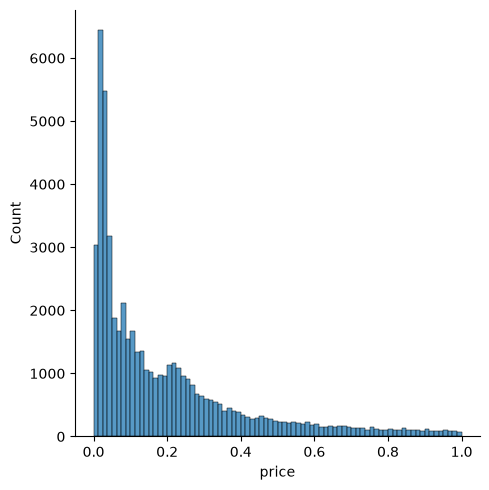

In [33]:
#if normally distrubted the mean and median will be the same

sns.displot(data , x ="price")

In [32]:
data["price"] = preproc.minmax_scale(data[["price"]])
# it will bring the max to 1 and the mix to very close to 0

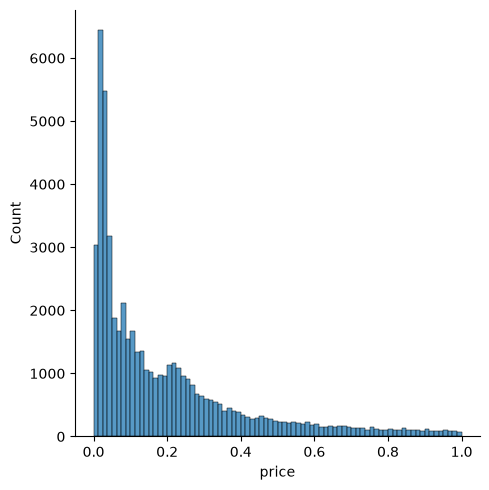

In [34]:
sns.displot(data , x ="price")

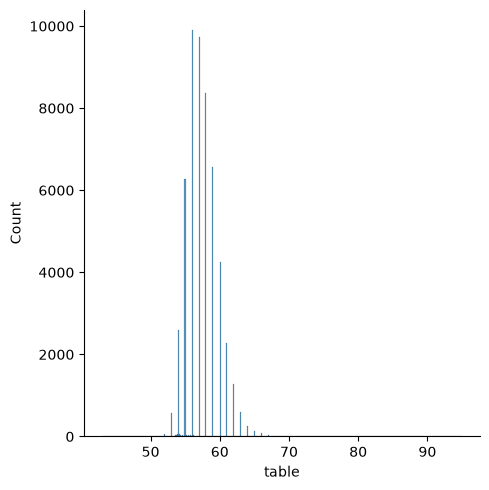

In [35]:
sns.displot(data, x ="table")

In [36]:
#since this is normal we use standard scaler, nice bell curve

In [37]:
data["table"] = preproc.StandardScaler().fit_transform(data[["table"]])
#tyically we would scfale since values are in the tens

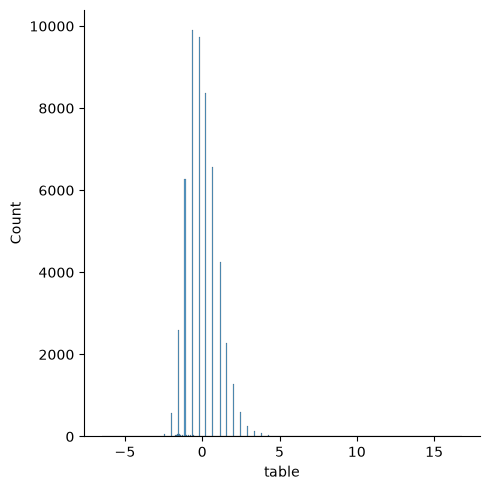

In [38]:
sns.displot(data, x ="table")

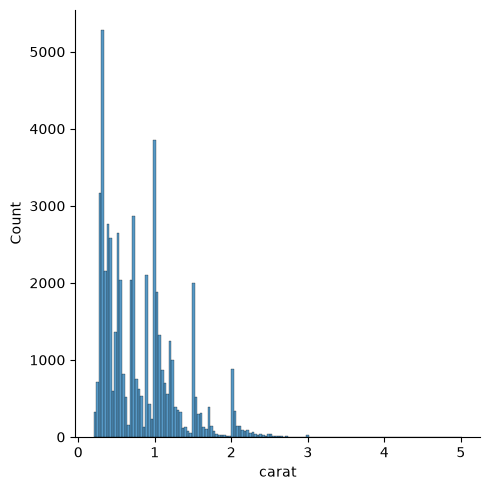

In [39]:
sns.displot(data, x ="carat")

In [40]:
#between o and 1 and 1 and 2. we have 1 diamond thats 5.4. Thats an outlier, it is skewed but has outlier
#we use the robust scaler
data["carat"] = preproc.RobustScaler().fit_transform(data[["carat"]])

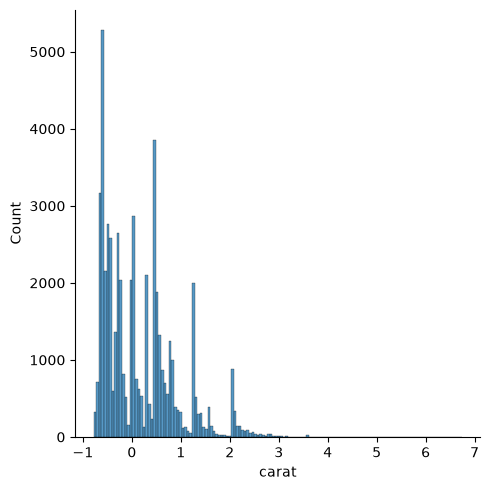

In [41]:
sns.displot(data, x ="carat")

In [42]:
#values have changed but the shape remains the same, which is why we use particulor ones for different data